# Brewster's Angle

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Plot I_parallel and I_perpendicular vs angle

### Horizontal Polarizer

In [101]:
# horizontal polarizer

# import data
ex3_01 = pd.read_csv("./Exercise3/Ex3_horiz01.txt", sep='\t', header=1, skiprows=0)
ex3_02 = pd.read_csv("./Exercise3/Ex3_horiz02.txt", sep='\t', header=1, skiprows=0)
ex3_03 = pd.read_csv("./Exercise3/Ex3_horiz03.txt", sep='\t', header=1, skiprows=0)

display(ex3_01.head())
display(ex3_03.tail())

ex3 = [ex3_01, ex3_02, ex3_03]
display(ex3[2].tail())

,Sensor Position (Degrees),Light Intensity (Volts)
0,180.0,-0.00182
1,180.0,-0.00263
2,180.0,-0.00247
3,180.0,-0.00279
4,180.0,-0.00102


,Sensor Position (Degrees),Light Intensity (Volts)
740,147.56667,0.00414
741,147.56667,0.00333
742,147.56667,0.00623
743,147.56667,0.00269
744,147.56667,0.00526


,Sensor Position (Degrees),Light Intensity (Volts)
740,147.56667,0.00414
741,147.56667,0.00333
742,147.56667,0.00623
743,147.56667,0.00269
744,147.56667,0.00526


2.5813419636996136
2.592104885597887
2.5749423649313257


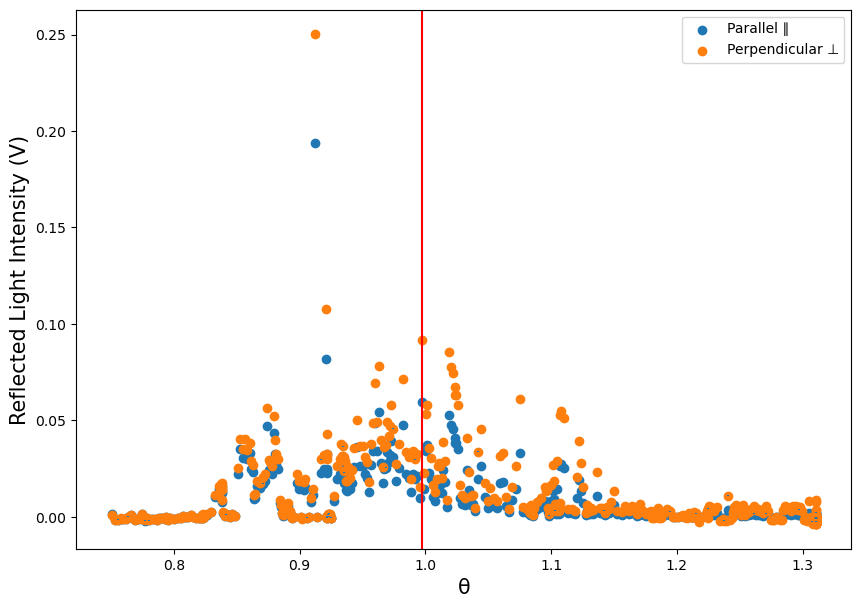

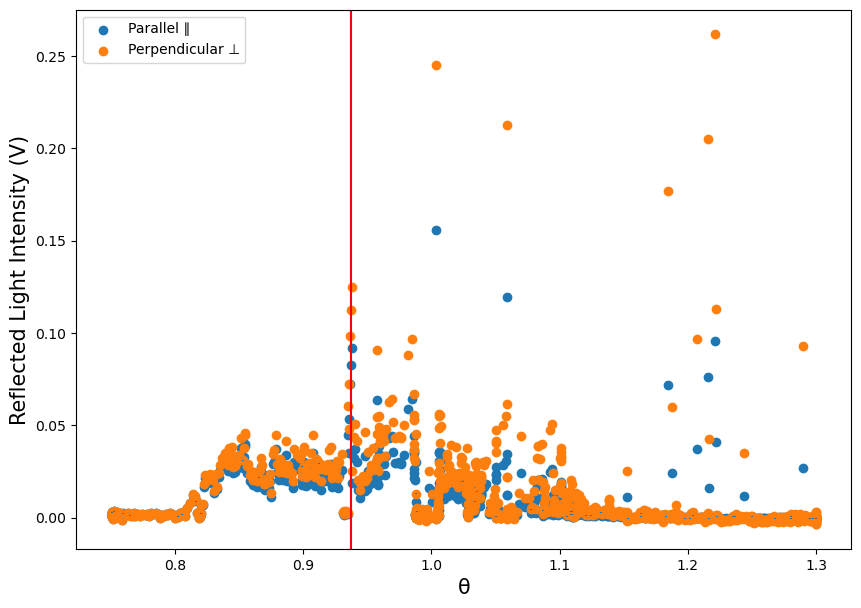

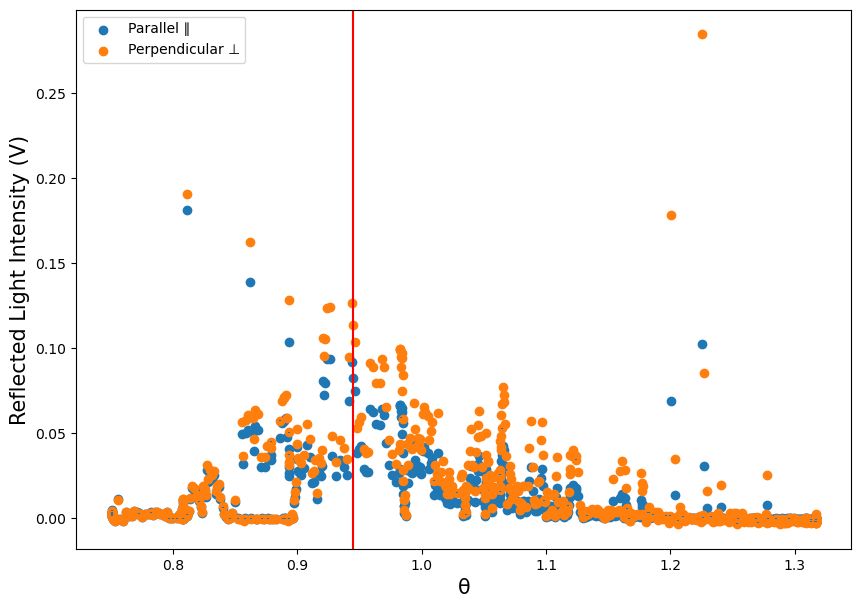

In [102]:
# plot
v = [0.997, 0.937, 0.945]

for i in range(0, len(ex3)):
    # make the data
    basic = ex3[i]['Sensor Position (Degrees)']
    shift = 43 * np.pi/180 # np.pi/3 ideally (?)
    print(np.min(basic) * np.pi/180) # min around 2.58
    x = np.array(((basic-np.min(basic))*np.pi/180 + shift).to_list()) # θ
    y1 = np.array(np.cos(x)*ex3[i]['Light Intensity (Volts)'].to_list()) # intensity parallel
    y2 = np.array(np.sin(x)*ex3[i]['Light Intensity (Volts)'].to_list()) # intensity parallel
    
    # MAKE ERRORBARS
    x_err = 0.00001 * np.pi/180
    y1_err = np.sqrt((-np.sin(x))**2 + 1) * 0.00001
    y2_err = np.sqrt((np.cos(x))**2 + 1) * 0.00001
    
    # plot
    fig, ax = plt.subplots()
    
    ax.scatter(x, y1, label="Parallel ∥")
    ax.scatter(x, y2, label="Perpendicular ⊥")
    ax.set_ylabel("Reflected Light Intensity (V)", fontsize=15)
    ax.set_xlabel("θ", fontsize=15)
    
    ax.errorbar(x, y1, xerr=x_err, yerr=y1_err, fmt='none')
    ax.errorbar(x, y2, xerr=x_err, yerr=y2_err, fmt='none')

    ax.axvline(x=v[i], color="red")
    
    ax.legend()
    fig.set_size_inches(10, 7)

    # save
    name = "./brewster/intensityvsangle_" + str(i) + ".png"
    fig.savefig(name, bbox_inches='tight', pad_inches=0.5)

In [108]:
# Calculate Brewster
brewster = np.mean(v)
brewster_unc = np.sqrt(np.var(v))
print(brewster)
print(brewster_unc)

0.9596666666666667
0.026599916457679996


In [111]:
# calculate index of refraction, n1=1 given

# value & unc
n2 = np.tan(v)
print(np.mean(n2))
print(np.sqrt(np.var(n2)))

# other unc calc
n2_unc = n2 * brewster_unc * (1/(np.sin(brewster) * np.cos(brewster)))
print(n2_unc)
print(np.mean(n2_unc))

1.4305106532460388
0.08303245617062374
[0.08757527 0.07701687 0.07832227]
0.08097146977522242


In [116]:
# Fresnel
other = np.pi/2 - np.array(v) # by def of brewster angle
r_per = [0] * len(v)
r_par = [0] * len(v)

for i in range(0, len(v)):
    r_per[i] = (np.cos(v[i]) - test2[i] * np.cos(other[i])) / (np.cos(v[i]) + test2[i] * np.cos(other[i]))
    r_par[i] = (np.cos(other[i]) - test2[i] * np.cos(v[i])) / (np.cos(other[i]) + test2[i] * np.cos(v[i]))

    print((np.cos(other[i]) - test2[i] * np.cos(v[i])))
    print((np.cos(other[i]) + test2[i] * np.cos(v[i])))
    print()

print(r_per)
print(r_par)
print()

print("perpendicular")
print(np.mean(r_per))
print(np.var(r_per)**0.5)

print("parallel")
print(np.mean(r_par))
print(np.var(r_par)**0.5)

0.6345380754714767
1.0451545119386427

0.5750036774062703
1.036566532544409

0.5336000913255372
1.0873937762500823

[0.2616883717224582, 0.30698556492143575, 0.2091044146061059]
[0.6071237010635688, 0.5547195084476025, 0.49071468218778747]

perpendicular
0.2592594504166666
0.03999670520426522
parallel
0.5508526305663196
0.04760237723277464


### Vertical Polarizer

In [117]:
# vertical polarizer

# import data
ex3_01 = pd.read_csv("./Exercise3/Ex3_vert01.txt", sep='\t', header=1, skiprows=0)
ex3_02 = pd.read_csv("./Exercise3/Ex3_vert02.txt", sep='\t', header=1, skiprows=0)
ex3_03 = pd.read_csv("./Exercise3/Ex3_vert03.txt", sep='\t', header=1, skiprows=0)

display(ex3_01.head())
display(ex3_03.tail())

ex3_vert = [ex3_01, ex3_02, ex3_03]
display(ex3[2].tail())

,Sensor Position (Degrees),Light Intensity (Volts)
0,180.0,1.08129
1,180.0,1.08065
2,180.0,1.08371
3,180.0,1.08645
4,180.0,1.08725


,Sensor Position (Degrees),Light Intensity (Volts)
586,146.38333,0.00333
587,146.38333,0.00188
588,146.38333,0.00108
589,146.38333,0.00188
590,146.38333,0.00462


,Sensor Position (Degrees),Light Intensity (Volts)
740,147.56667,0.00414
741,147.56667,0.00333
742,147.56667,0.00623
743,147.56667,0.00269
744,147.56667,0.00526


2.560688959061989
2.5359634031477607
2.5545803066800086


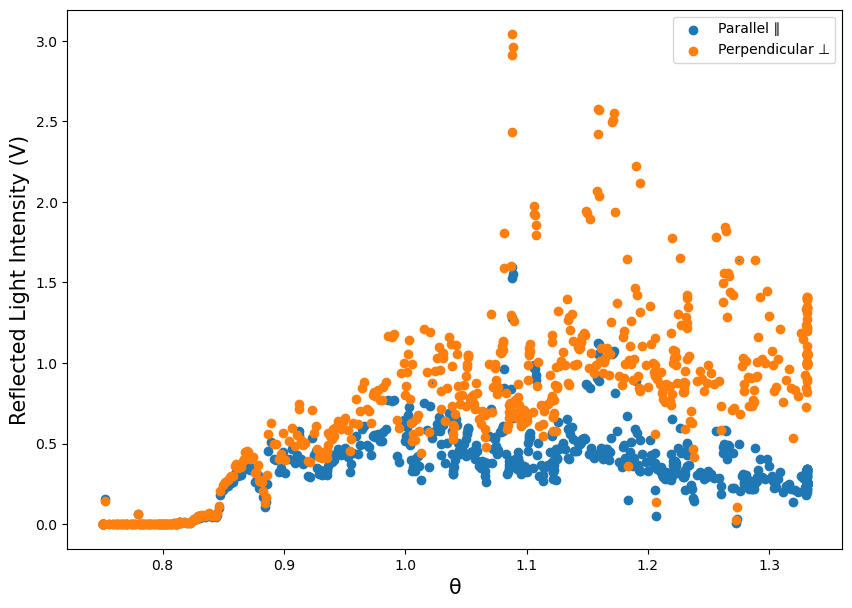

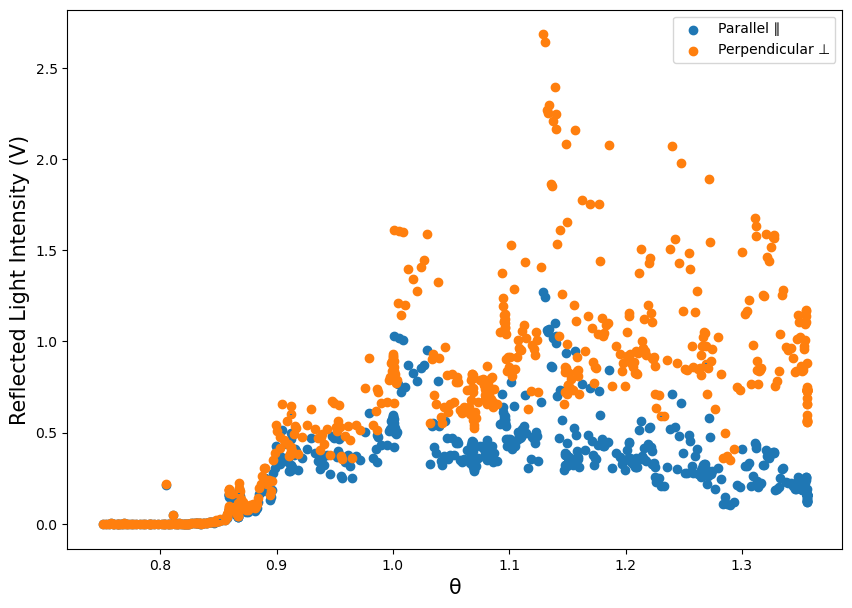

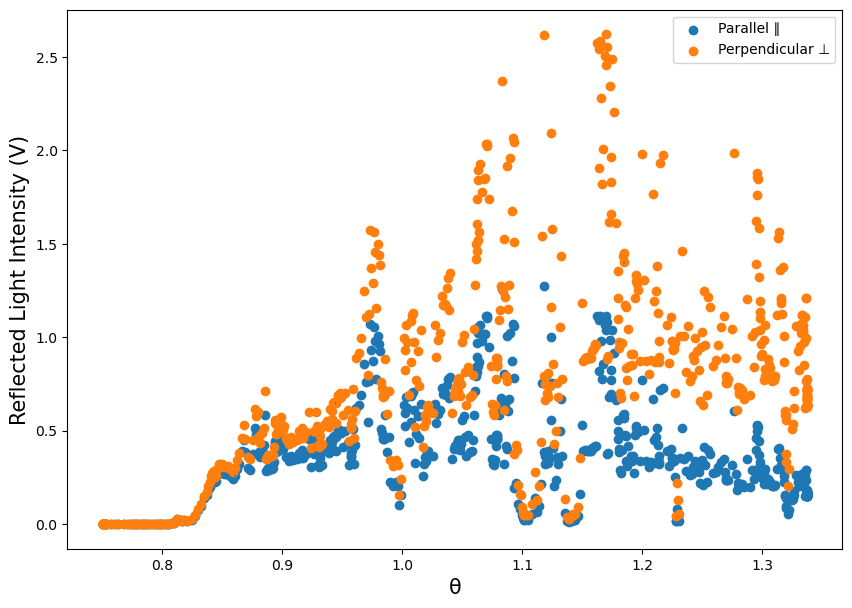

In [118]:
# plot
for i in range(0, len(ex3)):
   
    # make the data
    basic = ex3_vert[i]['Sensor Position (Degrees)']
    shift = 43 * np.pi/180 # np.pi/3 ideally (?)
    print(np.min(basic) * np.pi/180) # min around 2.58
    x = np.array(((basic-np.min(basic))*np.pi/180 + shift).to_list()) # θ
    y1 = np.array(np.cos(x)*ex3_vert[i]['Light Intensity (Volts)'].to_list()) # intensity parallel
    y2 = np.array(np.sin(x)*ex3_vert[i]['Light Intensity (Volts)'].to_list()) # intensity parallel
    
    # MAKE ERRORBARS
    x_err = 0.00001 * np.pi/180
    y1_err = np.sqrt((-np.sin(x))**2 + 1) * 0.00001
    y2_err = np.sqrt((np.cos(x))**2 + 1) * 0.00001
    
    # plot
    fig, ax = plt.subplots()
    
    ax.scatter(x, y1, label="Parallel ∥")
    ax.scatter(x, y2, label="Perpendicular ⊥")
    ax.set_ylabel("Reflected Light Intensity (V)", fontsize=15)
    ax.set_xlabel("θ", fontsize=15)

    ax.errorbar(x, y1, xerr=x_err, yerr=y1_err, fmt='none')
    ax.errorbar(x, y2, xerr=x_err, yerr=y2_err, fmt='none')

    #ax.axvline(x=v[i], color="red")
    
    ax.legend()
    #ax.errorbar(x, y, xerr=x_err, yerr=y_err[i], fmt='none')
    fig.set_size_inches(10, 7)

    # save
    name = "./brewster/intensityvsangle_vert_" + str(i) + ".png"
    fig.savefig(name, bbox_inches='tight', pad_inches=0.2)

## Fiddling

In [43]:
test = np.array([2.78, 2.77, 2.70])
print(np.mean(test))
print(np.sqrt(np.var(test)))

2.75
0.035590260840104235


In [66]:
test2 = np.tan(2*np.pi-test)
print(test2)
print(np.mean(test2))
print(np.sqrt(np.var(test2)))

[0.37822224 0.38969654 0.47272763]
0.41354880566225133
0.04210712336062612


In [80]:
brewster = np.array([2.78, 2.77, 2.70])-np.pi
other = np.pi/2 - brewster
print(other)

r_par = [0] * len(brewster)
r_per = [0] * len(brewster)
for i in range(0, len(brewster)):
    r_par[i] = (np.cos(brewster[i]) - test2[i] * np.cos(other[i])) / (np.cos(brewster[i]) + test2[i] * np.cos(other[i]))
    r_per[i] = (np.cos(other[i]) - test2[i] * np.cos(brewster[i])) / (np.cos(other[i]) + test2[i] * np.cos(brewster[i]))

    print((np.cos(other[i]) - test2[i] * np.cos(brewster[i])))
    print((np.cos(other[i]) + test2[i] * np.cos(brewster[i])))
    print()

print(r_par)
print(r_per)
print()

print(np.mean(r_par))
print(np.var(r_par)**0.5)

print(np.mean(r_per))
print(np.var(r_per)**0.5)

[1.93238898 1.94238898 2.01238898]
-0.7075286906022857
-1.1102230246251565e-16

-0.7261996944083362
-5.551115123125783e-17

-0.8547597604676591
-5.551115123125783e-17

[1.3338640760932987, 1.3581107014934954, 1.575565187359031]
[6372851894700778.0, 1.3082050692535804e+16, 1.5397982954933776e+16]

1.4225133216486086
0.10867575598665143
1.1617628514056786e+16
3827239814906779.5


## Discussion Qs

In [119]:
np.arctan(1.33)

0.9260932955034623